In [7]:
import json
from pathlib import Path
from notebook_utils import (
    get_model_schedule, stage_label,
    plot_interf_batch_times, plot_interf_throughput,
    print_interf_throughput_impact, plot_interf_optimizer_state,
    plot_interf_boxplot, plot_interf_stage_times,
)
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 120

## Configuration

In [8]:
INTERFERENCE_DIR = Path("interference")

# Select which interference run to load (filename without .json, or None for latest)
SELECTED_RUN = "gpipe-only"

# Optional: a non-interference baseline run from data/runs/ for comparison
BASELINE_RUN = "run41"
RUNS_DIR = Path("runs")

# Display options
SHOW_REBALANCE = False
SHOW_OPTIMUM = True
SHOW_INTERFERENCE_REGIONS = True  # shade background by interference step

In [9]:
# Load interference run
if SELECTED_RUN:
    interf_path = INTERFERENCE_DIR / f"{SELECTED_RUN}.json"
else:
    interf_files = sorted(INTERFERENCE_DIR.glob("*.json"))
    interf_path = interf_files[-1] if interf_files else None

with open(interf_path) as f:
    interf_data = json.load(f)

print(f"Loaded: {interf_path.stem}")

# Load baseline if specified
baseline_data = None
if BASELINE_RUN:
    baseline_path = RUNS_DIR / f"{BASELINE_RUN}.json"
    if baseline_path.exists():
        with open(baseline_path) as f:
            baseline_data = json.load(f)
        print(f"Baseline: {BASELINE_RUN}")
    else:
        print(f"Baseline not found: {baseline_path}")

Loaded: gpipe-only
Baseline: run41


## Run Summary

In [10]:
meta = interf_data.get("meta", {})
print(f"Schedule: {meta.get('schedule')}")
print(f"Optimizer: {meta.get('optimizer')}, kwargs: {meta.get('optimizer_kwargs')}")
print()

for model, result in interf_data["results"].items():
    steps, dur = get_model_schedule(interf_data, model)
    print(f"--- {model} ({len(steps)} steps x {dur}s) ---")
    for i, step in enumerate(steps):
        print(f"  Step {i}: {stage_label(step) if step else 'idle'}")

    batches = result.get("batches", [])
    timed = [b for b in batches if "timing" in b]
    rps = result.get("requests_per_second", 0)
    rebalances = sum(1 for b in batches if b.get("rebalance", {}).get("did_rebalance", False))
    at_optimum = sum(1 for b in batches if b.get("rebalance", {}).get("at_optimum", False))
    if timed:
        times = [b["timing"]["end"] - b["timing"]["start"] for b in timed]
        wall = timed[-1]["timing"]["end"] - timed[0]["timing"]["start"]
        print(f"  rps={rps:.2f}, batches={len(timed)}, rebalances={rebalances}, at_optimum={at_optimum}")
        print(f"  forward: avg={np.mean(times):.3f}s, min={min(times):.3f}s, max={max(times):.3f}s, wall={wall:.0f}s")
    print()

if baseline_data:
    print(f"--- Baseline ({BASELINE_RUN}) ---")
    for model, result in baseline_data["results"].items():
        print(f"  {model}: rps={result.get('requests_per_second', 0):.2f}")

Schedule: experiment
Optimizer: StaticGPipeOptimizer, kwargs: None

--- conv_next (4 steps x 240s) ---
  Step 0: idle
  Step 1: CPU×8
  Step 2: MEM×8
  Step 3: CPU×4 + MEM×4
  rps=21.23, batches=20256, rebalances=0, at_optimum=0
  forward: avg=1.435s, min=0.945s, max=2.549s, wall=954s

--- efficientnet_b6 (4 steps x 240s) ---
  Step 0: idle
  Step 1: CPU×8
  Step 2: MEM×8
  Step 3: CPU×4 + MEM×4
  rps=4.46, batches=4256, rebalances=0, at_optimum=0
  forward: avg=6.984s, min=5.611s, max=9.694s, wall=955s

--- Baseline (run41) ---
  conv_next: rps=32.78
  conv_next_base: rps=25.14
  efficientnet_b6: rps=5.53
  regnet_x_16gf: rps=18.41


## Batch Times with Interference Regions

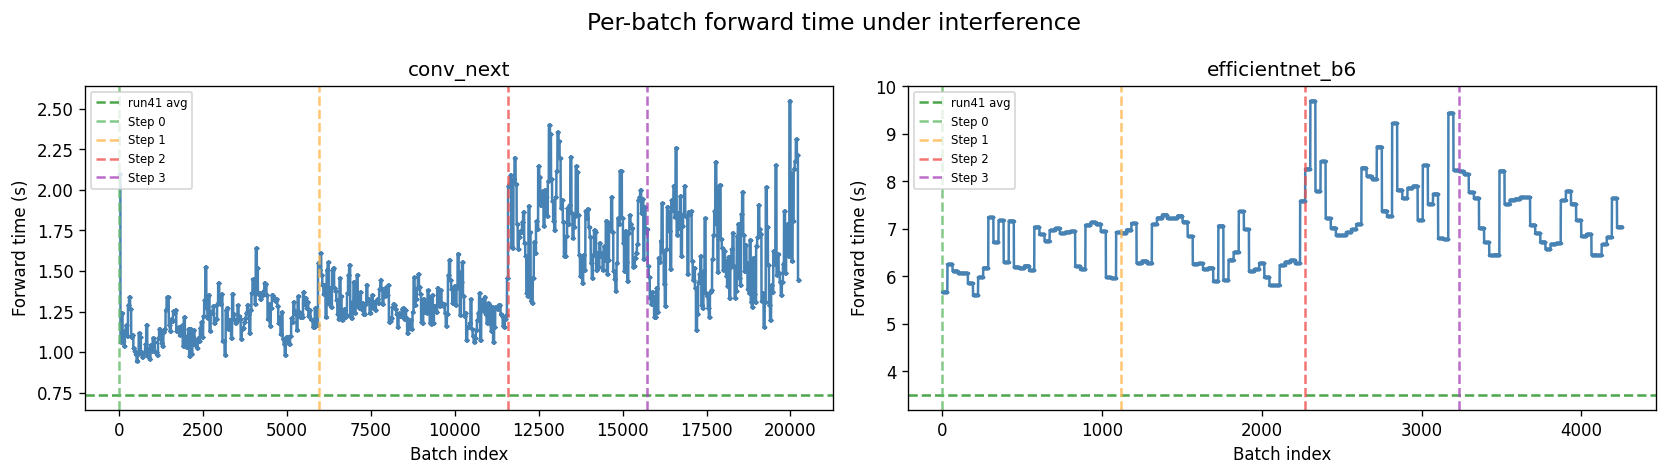

In [11]:
plot_interf_batch_times(interf_data, baseline_data, baseline_name=BASELINE_RUN,
                       show_interference_regions=SHOW_INTERFERENCE_REGIONS,
                       show_optimum=SHOW_OPTIMUM)

## Per-Stage Batch Times

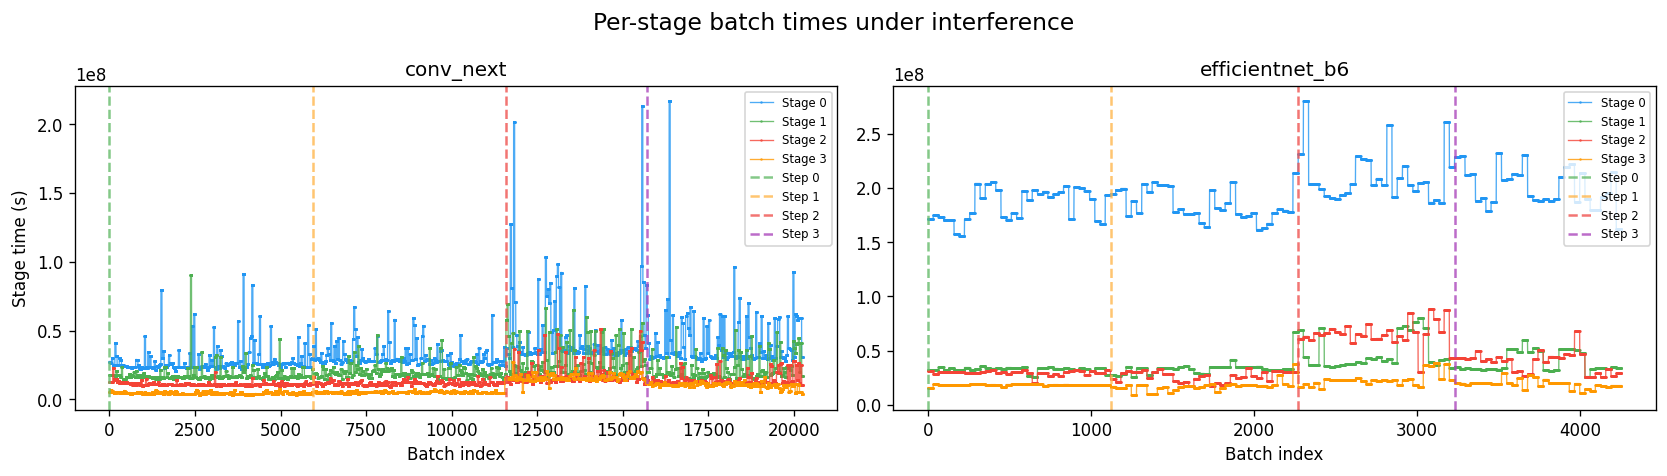

In [12]:
plot_interf_stage_times(interf_data,
                       show_interference_regions=SHOW_INTERFERENCE_REGIONS)

## Throughput Comparison (RPS)

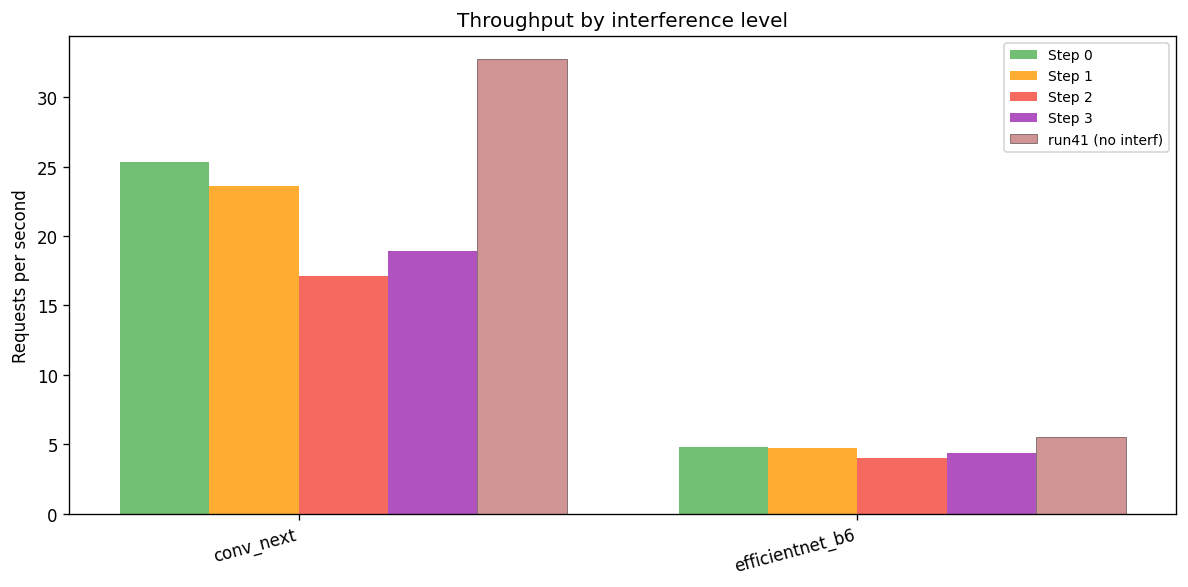

In [13]:
plot_interf_throughput(interf_data, baseline_data, baseline_name=BASELINE_RUN)

## Throughput Impact (%)

In [14]:
print_interf_throughput_impact(interf_data, baseline_data, baseline_name=BASELINE_RUN)

--- conv_next ---
  Step 0        25.37 rps (100.0%)
  Step 1        23.58 rps ( 93.0%)
  Step 2        17.15 rps ( 67.6%)
  Step 3        18.96 rps ( 74.7%)
  baseline      32.78 rps (129.2%)

--- efficientnet_b6 ---
  Step 0         4.77 rps (100.0%)
  Step 1         4.73 rps ( 99.2%)
  Step 2         4.01 rps ( 84.0%)
  Step 3         4.33 rps ( 90.8%)
  baseline       5.53 rps (116.1%)



## Optimizer State Under Interference

In [15]:
plot_interf_optimizer_state(interf_data,
                           show_interference_regions=SHOW_INTERFERENCE_REGIONS,
                           show_optimum=SHOW_OPTIMUM)

## Forward Time Distribution per Interference Step

In [ ]:
plot_interf_boxplot(interf_data)